In [1]:
# read in various csv files, the complete dataset and selected datasets
# plot histograms, density maps etc.
# finding means in a density plot to locate the corresponding MA

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# update if needed
#pip install --upgrade pandas seaborn

# Read in combined, all sca together
curRegion = 'CSSyl'
file_path = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined.csv'
combined = pd.read_csv(file_path)
combined.index = combined['subjName']
combined.index = combined.index.astype(str)

combined_L = combined[combined.index.str.startswith('L')]
combined_R = combined[combined.index.str.startswith('flip')]
combined_CAG = combined.dropna(subset=['CAG'])

#print(combined)
print(len(combined_L))

In [64]:
curRoot = 'C'  # 'C' or 'D'

# Load shape measures, SELECTED
curRegion = 'CS' # !!! modify !!! CSSyl, CSpreCS
curSCA = 7         # !!! modify !!!

# for CSpreCS analysis
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca1_time1_min.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca1_time1_max.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca2_time1_min.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca2_time1_max.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca3_time1_min.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca3_time1_max.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca7_time1_min.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca7_time1_max.csv'

#file_path_ctl_1_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'

# Time 1 and 2 separated, from combined set 
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_min.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_max.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time2_min.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time2_max.csv'

# Time 1 and 2 combined, from combined set 
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_and_2_min.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_and_2_max.csv'

# Time 1 and 2 combined, RELABEL, REDO, from combined set 
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}.csv'

# Time 1 and 2 combined, RELABEL, REDO, from combined set 
curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}_BIOSCA.csv'

#Original, time1 only
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_min.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_max.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_min.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_max.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_min.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_max.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_min.csv'

combined = pd.read_csv(curPath)

#############  only for time1 and 2 together  #############
#combined_time1 = combined[combined['Time_point']==1]
#combined_time2 = combined[combined['Time_point']!=1] # BIOSCA==2, CERMOI==3
#combined = combined_time1         ########    CHANGE    ########

combined.index = combined['subjName']

# for specific analysis
combined_L = combined[combined.index.str.startswith('L')]
combined_R = combined[combined.index.str.startswith('flip')]
combined_only_SCA = combined[combined['SCA'] == curSCA]

combined_CAG = combined.dropna(subset=['CAG'])
combined_CAG_only_SCA = combined_CAG[combined_CAG['SCA'] == curSCA]

combined_CCFS = combined.dropna(subset=['CCFS'])
combined_CCFS_only_SCA = combined_CCFS[combined_CCFS['SCA'] == curSCA]

combined_INAS = combined.dropna(subset=['INAS'])
combined_INAS_only_SCA = combined_INAS[combined_INAS['SCA'] == curSCA]

In [6]:
print(combined.columns)

Index(['subjName', 'label', 'surface_talairach', 'surface_native',
       'maxdepth_talairach', 'maxdepth_native', 'meandepth_talairach',
       'meandepth_native', 'hull_junction_length_talairach',
       'hull_junction_length_native', 'GM_thickness', 'opening',
       'Randomization', 'SCA', 'CAG', 'Sex', 'Age', 'SARA', 'INAS',
       'Time_point', 'CodeICM', 'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2',
       'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4', 'Age_onset',
       'Group_ctl_pre_pat', 'Handedness', 'CCFS', 'Disease_duration',
       'allele1', 'allele2', 'side', 'SCA_side', 'dominantSide',
       'SCA_dominantSide', 'iso1_asy', 'iso2_asy', 'iso3_asy', 'UMAP1_U1_asy',
       'UMAP1_U2_asy', 'UMAP1_U3_asy', 'UMAP2_U3_asy', 'UMAP1_U4_asy',
       'UMAP2_U4_asy', 'surface_talairach_asy', 'surface_native_asy',
       'maxdepth_talairach_asy', 'maxdepth_native_asy',
       'meandepth_talairach_asy', 'meandepth_native_asy',
       'hull_junction_length_talairach_asy', 'hull_

# Read in combined_sca_1_7, min and max
file_path_sca_1_7_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_sca1_7_max.csv'
combined_sca_1_7_max = pd.read_csv(file_path_sca_1_7_max)
combined_sca_1_7_max.index = combined_sca_1_7_max['subjName']
combined_sca_1_7_max.index = combined_sca_1_7_max.index.astype(str)

combined_sca_1_7_max_L = combined_sca_1_7_max[combined_sca_1_7_max.index.str.startswith('L')]
combined_sca_1_7_max_R = combined_sca_1_7_max[combined_sca_1_7_max.index.str.startswith('flip')]
combined_sca_1_7_max_CAG = combined_sca_1_7_max.dropna(subset=['CAG'])

#print(combined_sca_1_7_max)

file_path_sca_1_7_min = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_sca1_7_min.csv'
combined_sca_1_7_min = pd.read_csv(file_path_sca_1_7_min)
combined_sca_1_7_min.index = combined_sca_1_7_min['subjName']
combined_sca_1_7_min.index = combined_sca_1_7_min.index.astype(str)

combined_sca_1_7_min_L = combined_sca_1_7_min[combined_sca_1_7_min.index.str.startswith('L')]
combined_sca_1_7_min_R = combined_sca_1_7_min[combined_sca_1_7_min.index.str.startswith('flip')]
combined_sca_1_7_min_CAG = combined_sca_1_7_min.dropna(subset=['CAG'])

#print(combined_sca_1_7_min)


# Read in combined ctl_1_7, min

file_path_ctl_sca_1_7_min = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_7_min.csv'
combined_ctl_sca_1_7_min = pd.read_csv(file_path_ctl_sca_1_7_min)
combined_ctl_sca_1_7_min.index = combined_ctl_sca_1_7_min['subjName']
combined_ctl_sca_1_7_min.index = combined_ctl_sca_1_7_min.index.astype(str)

combined_ctl_sca_1_7_min_L = combined_ctl_sca_1_7_min[combined_ctl_sca_1_7_min.index.str.startswith('L')]
combined_ctl_sca_1_7_min_R = combined_ctl_sca_1_7_min[combined_ctl_sca_1_7_min.index.str.startswith('flip')]
combined_ctl_sca_1_7_min_CAG = combined_ctl_sca_1_7_min.dropna(subset=['CAG'])

print(combined_ctl_sca_1_7_min)

# Read in combined ctl_7, min and max
file_path_ctl_7_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_max.csv'
combined_ctl_7_max = pd.read_csv(file_path_ctl_7_max)
combined_ctl_7_max.index = combined_ctl_7_max['subjName']
combined_ctl_7_max.index = combined_ctl_7_max.index.astype(str)

combined_ctl_7_max_L = combined_ctl_7_max[combined_ctl_7_max.index.str.startswith('L')]
combined_ctl_7_max_R = combined_ctl_7_max[combined_ctl_7_max.index.str.startswith('flip')]
combined_ctl_7_max_CAG = combined_ctl_7_max.dropna(subset=['CAG'])

#print(combined_ctl_7_max)

file_path_ctl_7_min = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_min.csv'
combined_ctl_7_min = pd.read_csv(file_path_ctl_7_min)
combined_ctl_7_min.index = combined_ctl_7_min['subjName']
combined_ctl_7_min.index = combined_ctl_7_min.index.astype(str)

combined_ctl_7_min_L = combined_ctl_7_min[combined_ctl_7_min.index.str.startswith('L')]
combined_ctl_7_min_R = combined_ctl_7_min[combined_ctl_7_min.index.str.startswith('flip')]
combined_ctl_7_min_CAG = combined_ctl_7_min.dropna(subset=['CAG'])

#print(combined_ctl_7_min)


# Read in combined ctl_1, min and max
file_path_ctl_1_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'
combined_ctl_1_max = pd.read_csv(file_path_ctl_1_max)
combined_ctl_1_max.index = combined_ctl_1_max['subjName']
combined_ctl_1_max.index = combined_ctl_1_max.index.astype(str)

combined_ctl_1_max_L = combined_ctl_1_max[combined_ctl_1_max.index.str.startswith('L')]
combined_ctl_1_max_R = combined_ctl_1_max[combined_ctl_1_max.index.str.startswith('flip')]
combined_ctl_1_max_CAG = combined_ctl_1_max.dropna(subset=['CAG'])

#print(combined_ctl_1_max)

file_path_ctl_1_min = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_min.csv'
combined_ctl_1_min = pd.read_csv(file_path_ctl_1_min)
combined_ctl_1_min.index = combined_ctl_1_min['subjName']
combined_ctl_1_min.index = combined_ctl_1_min.index.astype(str)

combined_ctl_1_min_L = combined_ctl_1_min[combined_ctl_1_min.index.str.startswith('L')]
combined_ctl_1_min_R = combined_ctl_1_min[combined_ctl_1_min.index.str.startswith('flip')]
combined_ctl_1_min_CAG = combined_ctl_1_min.dropna(subset=['CAG'])

#print(combined_ctl_1_min)


# Read in combined ctl_2, max
file_path_ctl_2_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_max.csv'
combined_ctl_2_max = pd.read_csv(file_path_ctl_2_max)
combined_ctl_2_max.index = combined_ctl_2_max['subjName']
combined_ctl_2_max.index = combined_ctl_2_max.index.astype(str)

combined_ctl_2_max_L = combined_ctl_2_max[combined_ctl_2_max.index.str.startswith('L')]
combined_ctl_2_max_R = combined_ctl_2_max[combined_ctl_2_max.index.str.startswith('flip')]
combined_ctl_2_max_CAG = combined_ctl_2_max.dropna(subset=['CAG'])

#print(combined_ctl_2_max)

# Read in combined ctl_3, max
file_path_ctl_3_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_max.csv'
combined_ctl_3_max = pd.read_csv(file_path_ctl_3_max)
combined_ctl_3_max.index = combined_ctl_3_max['subjName']
combined_ctl_3_max.index = combined_ctl_3_max.index.astype(str)

combined_ctl_3_max_L = combined_ctl_3_max[combined_ctl_3_max.index.str.startswith('L')]
combined_ctl_3_max_R = combined_ctl_3_max[combined_ctl_3_max.index.str.startswith('flip')]
combined_ctl_3_max_CAG = combined_ctl_3_max.dropna(subset=['CAG'])


# Read in combined BIOSCA, max
file_path_BIOSCA_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_BIOSCA_max.csv'
combined_BIOSCA_max = pd.read_csv(file_path_BIOSCA_max)
combined_BIOSCA_max.index = combined_BIOSCA_max['subjName']
combined_BIOSCA_max.index = combined_BIOSCA_max.index.astype(str)

combined_BIOSCA_max_L = combined_BIOSCA_max[combined_BIOSCA_max.index.str.startswith('L')]
combined_BIOSCA_max_R = combined_BIOSCA_max[combined_BIOSCA_max.index.str.startswith('flip')]
combined_BIOSCA_max_CAG = combined_BIOSCA_max.dropna(subset=['CAG'])


# Read in combined CERMOI, min
file_path_CERMOI_min = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_CERMOI_min.csv'
combined_CERMOI_min = pd.read_csv(file_path_CERMOI_min)
combined_CERMOI_min.index = combined_CERMOI_min['subjName']
combined_CERMOI_min.index = combined_CERMOI_min.index.astype(str)

combined_CERMOI_min_L = combined_CERMOI_min[combined_CERMOI_min.index.str.startswith('L')]
combined_CERMOI_min_R = combined_CERMOI_min[combined_CERMOI_min.index.str.startswith('flip')]
combined_CERMOI_min_CAG = combined_CERMOI_min.dropna(subset=['CAG'])


# Read in combined CERMOI, max
file_path_CERMOI_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_CERMOI_max.csv'
combined_CERMOI_max = pd.read_csv(file_path_CERMOI_max)
combined_CERMOI_max.index = combined_CERMOI_max['subjName']
combined_CERMOI_max.index = combined_CERMOI_max.index.astype(str)

combined_CERMOI_max_L = combined_CERMOI_max[combined_CERMOI_max.index.str.startswith('L')]
combined_CERMOI_max_R = combined_CERMOI_max[combined_CERMOI_max.index.str.startswith('flip')]
combined_CERMOI_max_CAG = combined_CERMOI_max.dropna(subset=['CAG'])

# Read in combined 1_2, max
file_path_1_2_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_sca_1_2_max.csv'
combined_1_2_max = pd.read_csv(file_path_1_2_max)
combined_1_2_max.index = combined_1_2_max['subjName']
combined_1_2_max.index = combined_1_2_max.index.astype(str)

combined_1_2_max_L = combined_1_2_max[combined_1_2_max.index.str.startswith('L')]
combined_1_2_max_R = combined_1_2_max[combined_1_2_max.index.str.startswith('flip')]
combined_1_2_max_CAG = combined_1_2_max.dropna(subset=['CAG'])

#print(combined_1_2_max)

# Read in combined 2_3, min
file_path_2_3_min = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_sca_2_3_min.csv'
combined_2_3_min = pd.read_csv(file_path_2_3_min)
combined_2_3_min.index = combined_2_3_min['subjName']
combined_2_3_min.index = combined_2_3_min.index.astype(str)

combined_2_3_min_L = combined_2_3_min[combined_2_3_min.index.str.startswith('L')]
combined_2_3_min_R = combined_2_3_min[combined_2_3_min.index.str.startswith('flip')]
combined_2_3_min_CAG = combined_2_3_min.dropna(subset=['CAG'])

#print(combined_2_3_min)

# Read in combined BIOSCA_1_2, min
file_path_BIOSCA_1_2_min = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_BIOSCA_sca_1_2_min.csv'
combined_BIOSCA_1_2_min = pd.read_csv(file_path_BIOSCA_1_2_min)
combined_BIOSCA_1_2_min.index = combined_BIOSCA_1_2_min['subjName']
combined_BIOSCA_1_2_min.index = combined_BIOSCA_1_2_min.index.astype(str)

combined_BIOSCA_1_2_min_L = combined_BIOSCA_1_2_min[combined_BIOSCA_1_2_min.index.str.startswith('L')]
combined_BIOSCA_1_2_min_R = combined_BIOSCA_1_2_min[combined_BIOSCA_1_2_min.index.str.startswith('flip')]
combined_BIOSCA_1_2_min_CAG = combined_BIOSCA_1_2_min.dropna(subset=['CAG'])

# Read in combined BIOSCA_1_2, max
file_path_BIOSCA_1_2_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_BIOSCA_sca_1_2_max.csv'
combined_BIOSCA_1_2_max = pd.read_csv(file_path_BIOSCA_1_2_max)
combined_BIOSCA_1_2_max.index = combined_BIOSCA_1_2_max['subjName']
combined_BIOSCA_1_2_max.index = combined_BIOSCA_1_2_max.index.astype(str)

combined_BIOSCA_1_2_max_L = combined_BIOSCA_1_2_max[combined_BIOSCA_1_2_max.index.str.startswith('L')]
combined_BIOSCA_1_2_max_R = combined_BIOSCA_1_2_max[combined_BIOSCA_1_2_max.index.str.startswith('flip')]
combined_BIOSCA_1_2_max_CAG = combined_BIOSCA_1_2_max.dropna(subset=['CAG'])

# Read in combined BIOSCA_2_3, min
file_path_BIOSCA_2_3_min = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_BIOSCA_sca_2_3_min.csv'
combined_BIOSCA_2_3_min = pd.read_csv(file_path_BIOSCA_2_3_min)
combined_BIOSCA_2_3_min.index = combined_BIOSCA_2_3_min['subjName']
combined_BIOSCA_2_3_min.index = combined_BIOSCA_2_3_min.index.astype(str)

combined_BIOSCA_2_3_min_L = combined_BIOSCA_2_3_min[combined_BIOSCA_2_3_min.index.str.startswith('L')]
combined_BIOSCA_2_3_min_R = combined_BIOSCA_2_3_min[combined_BIOSCA_2_3_min.index.str.startswith('flip')]
combined_BIOSCA_2_3_min_CAG = combined_BIOSCA_2_3_min.dropna(subset=['CAG'])

# Read in combined BIOSCA_2_3, max
file_path_BIOSCA_2_3_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_BIOSCA_sca_2_3_max.csv'
combined_BIOSCA_2_3_max = pd.read_csv(file_path_BIOSCA_2_3_max)
combined_BIOSCA_2_3_max.index = combined_BIOSCA_2_3_max['subjName']
combined_BIOSCA_2_3_max.index = combined_BIOSCA_2_3_max.index.astype(str)

combined_BIOSCA_2_3_max_L = combined_BIOSCA_2_3_max[combined_BIOSCA_2_3_max.index.str.startswith('L')]
combined_BIOSCA_2_3_max_R = combined_BIOSCA_2_3_max[combined_BIOSCA_2_3_max.index.str.startswith('flip')]
combined_BIOSCA_2_3_max_CAG = combined_BIOSCA_2_3_max.dropna(subset=['CAG'])



In [19]:
# To avoid certain warnings when plotting
combined.replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace Inf with NaN
combined.dropna(subset=['iso3'], inplace=True)  # Drop NaNs in the 'iso3' column

# Defining the custom palette
custom_palette = {
    0: '#1f77b4',  # Blue
    1: '#ff7f0e',  # Orange
    2: '#2ca02c',  # Green
    3: '#d62728',  # Red
    7: '#9467bd'   # Purple
}
#custom_palette = sns.color_palette("Set2")  # Predefined palette

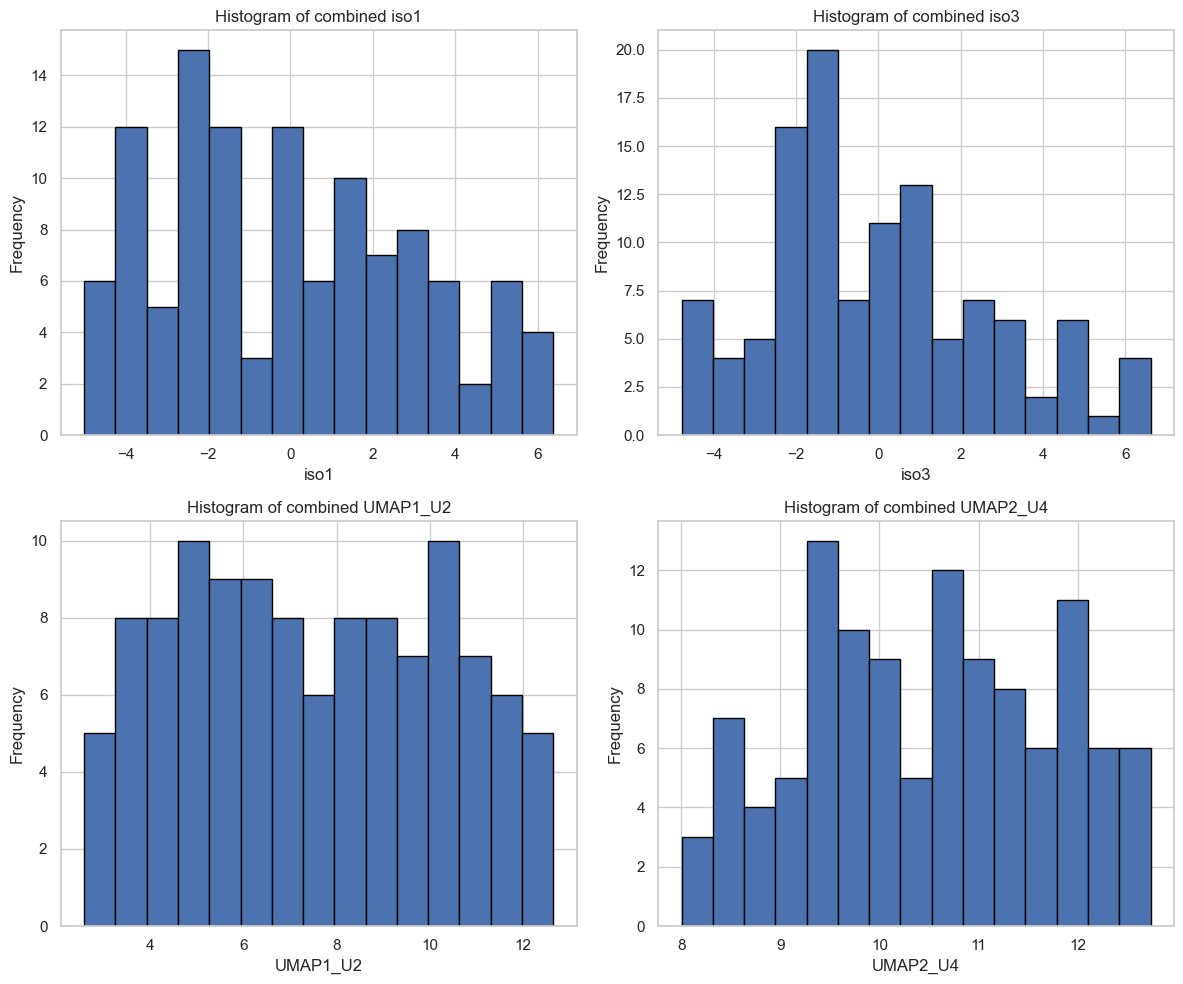

In [66]:
# Histograms of different shape measures

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

curVal = 'iso1'
axs[0, 0].hist(combined[curVal], bins=15, edgecolor='black')
axs[0, 0].set_title('Histogram of combined ' + curVal)
axs[0, 0].set_xlabel(curVal)
axs[0, 0].set_ylabel('Frequency')

curVal = 'iso3'
axs[0, 1].hist(combined[curVal], bins=15, edgecolor='black')
axs[0, 1].set_title('Histogram of combined ' + curVal)
axs[0, 1].set_xlabel(curVal)
axs[0, 1].set_ylabel('Frequency')

curVal = 'UMAP1_U2'
axs[1, 0].hist(combined[curVal], bins=15, edgecolor='black')
axs[1, 0].set_title('Histogram of combined ' + curVal)
axs[1, 0].set_xlabel(curVal)
axs[1, 0].set_ylabel('Frequency')

curVal = 'UMAP2_U4'
axs[1, 1].hist(combined[curVal], bins=15, edgecolor='black')
axs[1, 1].set_title('Histogram of combined ' + curVal)
axs[1, 1].set_xlabel(curVal)
axs[1, 1].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()
# save the plot
#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots\histo_iso12_U1112.png')
# Show the plot
plt.show()

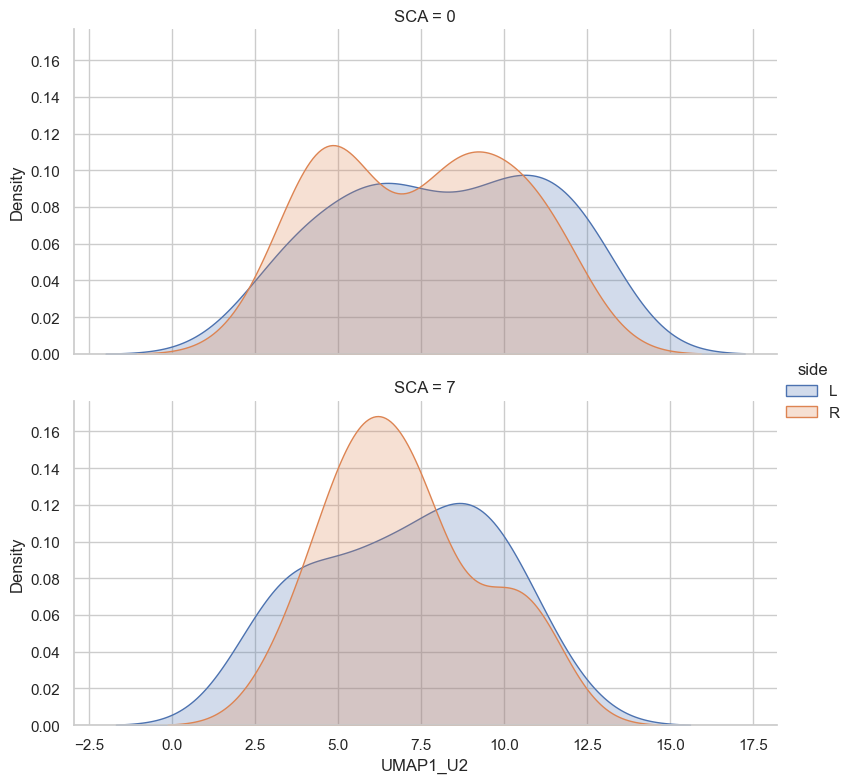

In [74]:
# plot the asymmetry pattern by type of SCA

# Create FacetGrid with 'Category1' as the rows and 'Category2' as the hue
g = sns.FacetGrid(combined, row='SCA', hue='side', height=4, aspect=2)
#g.map(sns.kdeplot, 'iso1', fill=True)
g.map(sns.kdeplot, 'UMAP1_U2', fill=True)
g.add_legend()

#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots\density_combined_U14_side.png')
#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_ageOnsetAgeSide.png')
#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA7\SCA7_ctl_minU12_density_bySCA.png')
plt.show()

C:\Users\joyca\AppData\Local\Temp\ipykernel_57356\3641052158.py:10: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.kdeplot(data=combined_L, x=curVal, hue='SCA', fill=True, palette=custom_palette, ax=axs[0])
C:\Users\joyca\AppData\Local\Temp\ipykernel_57356\3641052158.py:16: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.kdeplot(data=combined_R, x=curVal, hue='SCA', fill=True, palette=custom_palette, ax=axs[1])


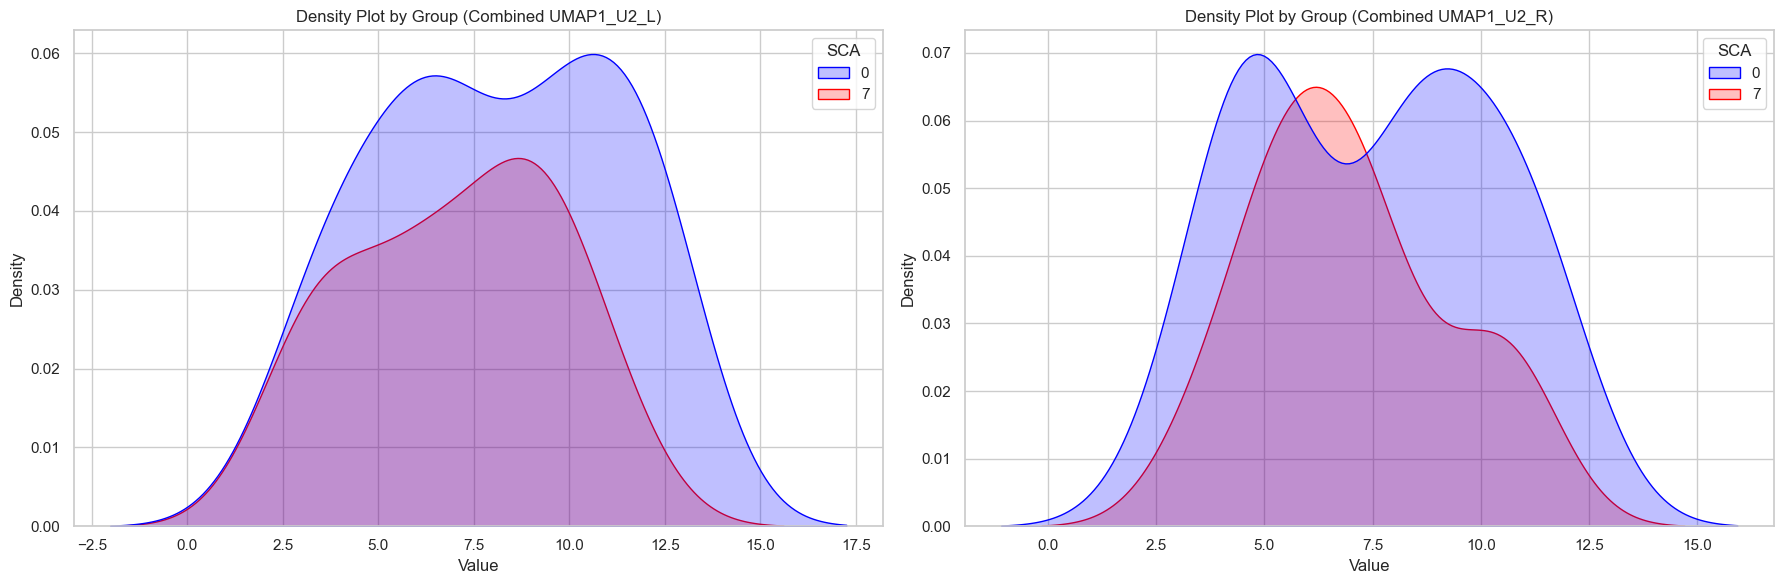

In [76]:
# Compare the asymmetry patterns by hemisphere

custom_palette = ['blue', 'red', 'green', 'orange', 'purple']
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

#curVal = 'iso1'
curVal = 'UMAP1_U2'

# First plot
sns.kdeplot(data=combined_L, x=curVal, hue='SCA', fill=True, palette=custom_palette, ax=axs[0])
axs[0].set_title('Density Plot by Group (Combined ' + curVal + '_L)')
axs[0].set_xlabel('Value')
axs[0].set_ylabel('Density')

# Second plot
sns.kdeplot(data=combined_R, x=curVal, hue='SCA', fill=True, palette=custom_palette, ax=axs[1])
axs[1].set_title('Density Plot by Group (Combined ' + curVal + '_R)')
axs[1].set_xlabel('Value')
axs[1].set_ylabel('Density')

# Adjust layout for better spacing
plt.tight_layout()

#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots_CSSyl\density_ctl_sca1_iso1max_LR.png')
#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_ageOnsetAgeSide_byHem.png')
#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA7\SCA7_ctl_minU12_density_byHem.png')

# Show the plots
plt.show()

C:\Users\joyca\AppData\Local\Temp\ipykernel_57356\407012049.py:11: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.kdeplot(data=combined, x=curVal1, hue='SCA', fill=True, palette=custom_palette, ax=axs[0])
C:\Users\joyca\AppData\Local\Temp\ipykernel_57356\407012049.py:17: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.kdeplot(data=combined, x=curVal2, hue='SCA', fill=True, palette=custom_palette, ax=axs[1])


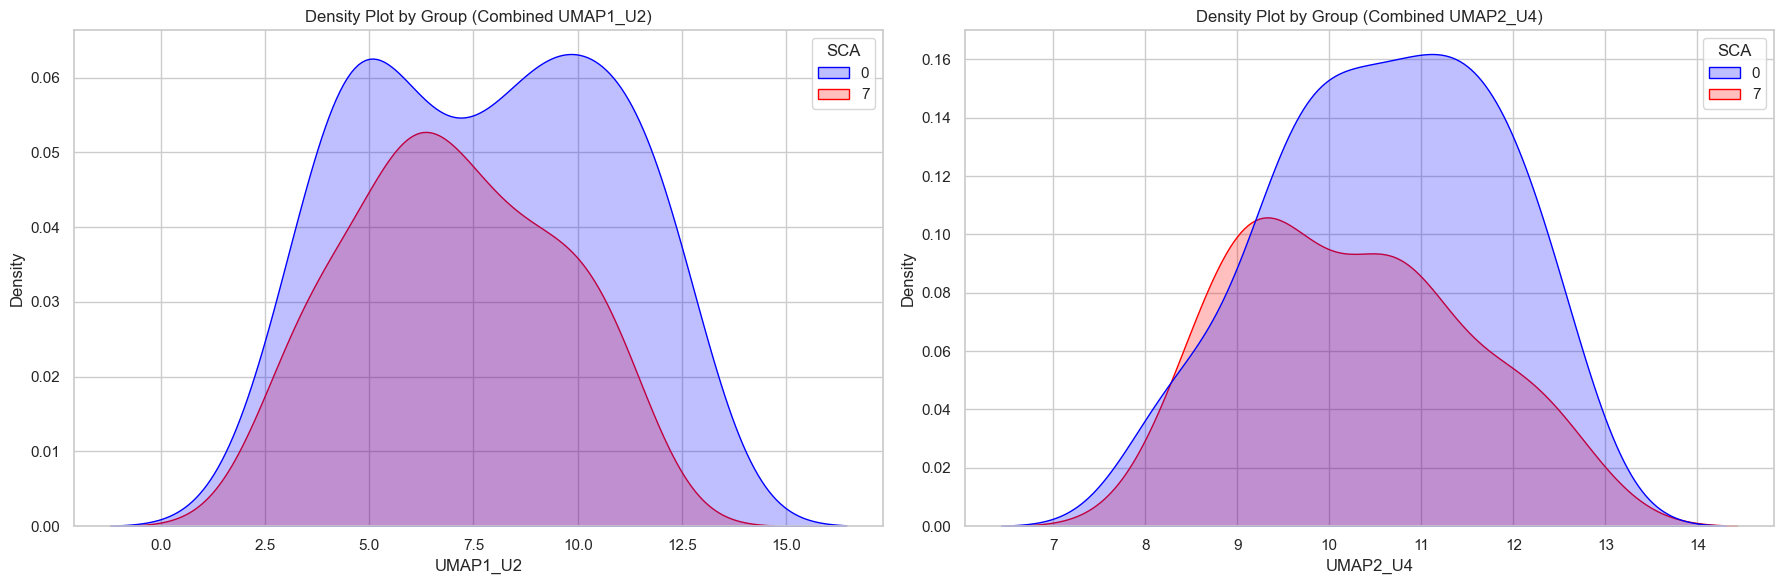

In [78]:
# Density plots: compare the distribution patterns of different shape measures, two hemisphere combined
#curVal1 = 'iso1'
#curVal2 = 'iso3'
curVal1 = 'UMAP1_U2'
curVal2 = 'UMAP2_U4'

fig, axs = plt.subplots(1, 2, figsize=(18, 6))
custom_palette = ['blue', 'red', 'green', 'orange', 'purple']

# First plot
sns.kdeplot(data=combined, x=curVal1, hue='SCA', fill=True, palette=custom_palette, ax=axs[0])
axs[0].set_title('Density Plot by Group (Combined ' + curVal1 +')')
axs[0].set_xlabel(curVal1)
axs[0].set_ylabel('Density')

# Second plot
sns.kdeplot(data=combined, x=curVal2, hue='SCA', fill=True, palette=custom_palette, ax=axs[1])
axs[1].set_title('Density Plot by Group (Combined '+curVal2+')')
axs[1].set_xlabel(curVal2)
axs[1].set_ylabel('Density')

# Adjust layout for better spacing
plt.tight_layout()

#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\density_max_iso1_UMAP2_U4.png')

# Show the plots
plt.show()


C:\Users\joyca\AppData\Local\Temp\ipykernel_57356\475409210.py:14: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.kdeplot(data=combined, x=curVal1, hue='SCA', fill=True, palette=custom_palette)


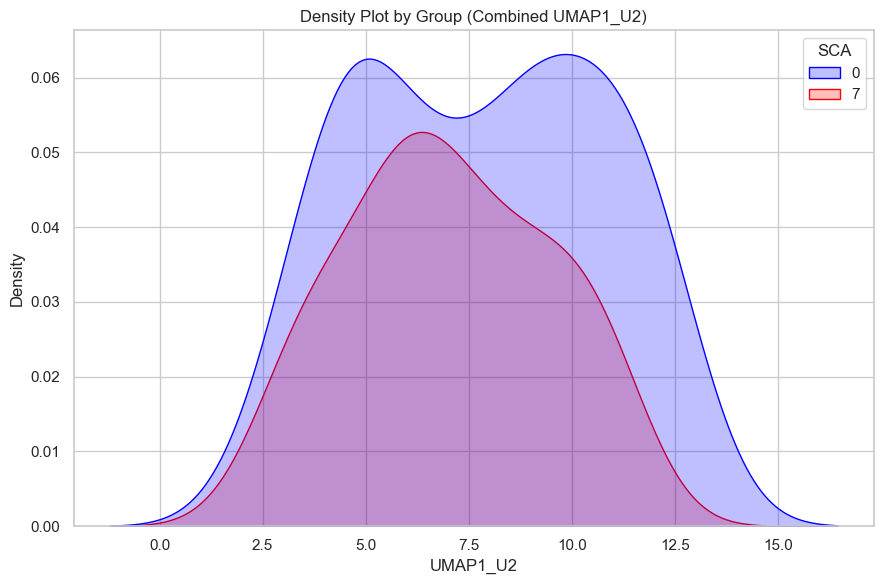

In [86]:
# same as above, but only one plot instead of two
# Density plots: compare the distribution patterns of different shape measures, two hemisphere combined
#curVal1 = 'iso1'
#curVal2 = 'iso3'
curVal1 = 'UMAP1_U2'
curVal2 = 'UMAP2_U4'

custom_palette = ['blue', 'red', 'green', 'orange', 'purple']

# Create a single plot
plt.figure(figsize=(9, 6))

# First plot
sns.kdeplot(data=combined, x=curVal1, hue='SCA', fill=True, palette=custom_palette)
plt.title('Density Plot by Group (Combined ' + curVal1 +')')
plt.xlabel(curVal1)
plt.ylabel('Density')

# Adjust layout for better spacing
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA7\SCA7_ctl_minU12_density.png')

# Show the plots
plt.show()


C:\Users\joyca\AppData\Local\Temp\ipykernel_57356\1538477132.py:13: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.kdeplot(data=combined, x=curVal, hue='SCA_side', fill=True, palette=custom_palette)


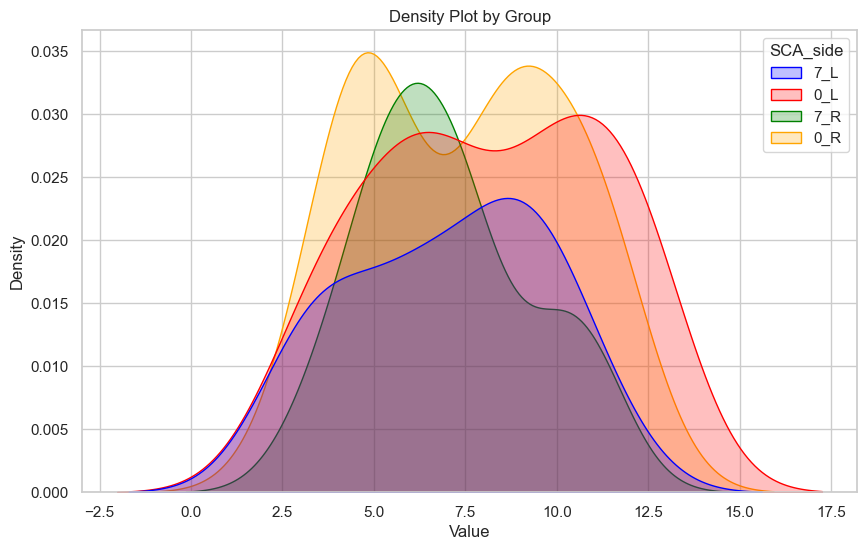

In [90]:
# Plotting the SCA type and hemispheres all together for comparison
custom_palette = ['blue', 'red', 'green', 'orange', 'purple']

#curVal = 'iso1'
curVal = 'UMAP1_U2'

filtered_combined = combined[combined['SCA_side'].isin(['1_L','1_R', '7_L','7_R', '0_L', '0_R'])]
#filtered_combined = combined[combined['SCA_side'].isin(['1_L','1_R', '3_L','3_R', '7_L','7_R','0_L','0_R'])]
#filtered_combined = combined[combined['SCA_side'].isin(['1_L','2_L', '3_L','4_L', '7_L','0_L','2_R'])]
#filtered_combined = combined[combined['SCA_side'].isin(['2_L','2_R', '7_L','7_R'])]

plt.figure(figsize=(10, 6))
sns.kdeplot(data=combined, x=curVal, hue='SCA_side', fill=True, palette=custom_palette)
#sns.kdeplot(data=filtered_combined, x=curVal, hue='SCA_side', fill=True) # default colors

# Customize the plot
plt.title('Density Plot by Group')
plt.xlabel('Value')
plt.ylabel('Density')

#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots\density_combined_SCA17_side_U014.png')
#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_ageOnsetAgeSide_HemSca.png')
#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA7\SCA7_ctl_minU12_density_by_Hem_Sca.png')


In [25]:
combined.info

<bound method DataFrame.info of                           subjName    label  surface_talairach  \
subjName                                                         
L001013LF_E1          L001013LF_E1  b'S.C.'            3928.88   
L001015VJ_E1          L001015VJ_E1  b'S.C.'            4982.84   
L001019DA_E1          L001019DA_E1  b'S.C.'            4437.42   
L001020HG_E1          L001020HG_E1  b'S.C.'            5164.57   
L001022LM_E1          L001022LM_E1  b'S.C.'            5684.75   
...                            ...      ...                ...   
flip-R00023EA_V3  flip-R00023EA_V3  b'S.C.'            4514.43   
flip-R00027EF_V3  flip-R00027EF_V3  b'S.C.'            4483.01   
flip-R00030CA_V3  flip-R00030CA_V3  b'S.C.'            5301.72   
flip-R00031CP_V3  flip-R00031CP_V3  b'S.C.'            4051.58   
flip-R00036DC_V3  flip-R00036DC_V3  b'S.C.'            4367.87   

                  surface_native  maxdepth_talairach  maxdepth_native  \
subjName                            

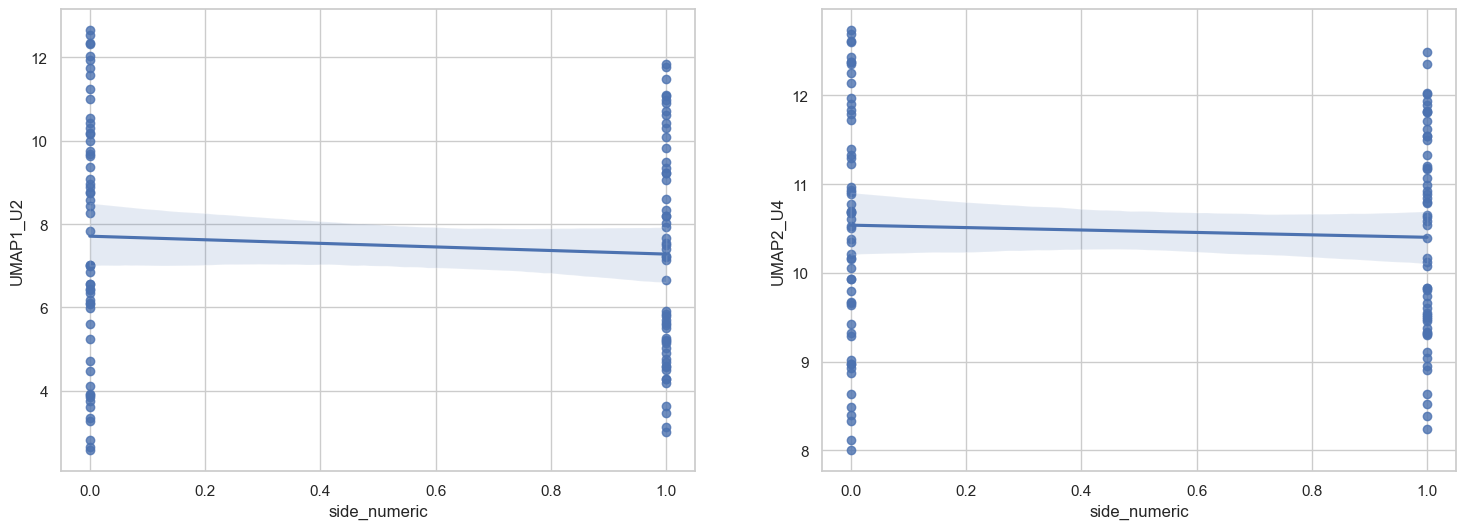

In [94]:
# Compare the effects of a given measure (eg. side) on the distribution patterns, plot a regression line
# Independant variables, predictor: curMeasure
# Dependant variables, response: corMeasure
corMeasure1 = 'UMAP1_U2' 
curMeasure1 = 'side_numeric' # 'Sex', 'Age', 'Age_onset', 'side_numeric'
corMeasure2 =  'UMAP2_U4'
curMeasure2 = 'side_numeric' # 'Sex', 'Age', 'Age_onset', 'side_numeric'

combined_no_inf = combined.replace([np.inf, -np.inf], np.nan)
combined_no_inf['side_numeric'] = combined_no_inf['side'].map({'L': 0, 'R': 1})

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # Create a figure with two subplots
sns.set(style="white", palette="muted")

sns.regplot(x=curMeasure1, y=corMeasure1, data=combined_no_inf,ax=axes[0])  # Removed height and ratio arguments
sns.regplot(x=curMeasure2, y=corMeasure2, data=combined_no_inf,ax=axes[1])  # Removed height and ratio arguments

plt.show()

In [96]:
# Continuing the cell above, display the ststistical results

import statsmodels.api as sm

# Define your x (independent variable) and y (dependent variable)
x = combined_no_inf[curMeasure1]  # Predictor
y = combined_no_inf[corMeasure1]  # Response
# Add a constant term for the intercept
x = sm.add_constant(x)
# Fit the model
model = sm.OLS(y, x).fit()
# Print the summary
print(model.summary())

x = combined_no_inf[curMeasure2]  # Predictor
y = combined_no_inf[corMeasure2]  # Response
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               UMAP1_U2   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.6805
Date:                Thu, 22 May 2025   Prob (F-statistic):              0.411
Time:                        15:01:59   Log-Likelihood:                -277.43
No. Observations:                 114   AIC:                             558.9
Df Residuals:                     112   BIC:                             564.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            7.7091      0.369     20.914   

C:\Users\joyca\AppData\Local\Temp\ipykernel_57356\45662263.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SCA', y=curVal1, data=combined, palette='Set2', ax=axes[0])
C:\Users\joyca\AppData\Local\Temp\ipykernel_57356\45662263.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='SCA', y=curVal2, data=combined, palette='Set2', inner='quartile', ax=axes[1])


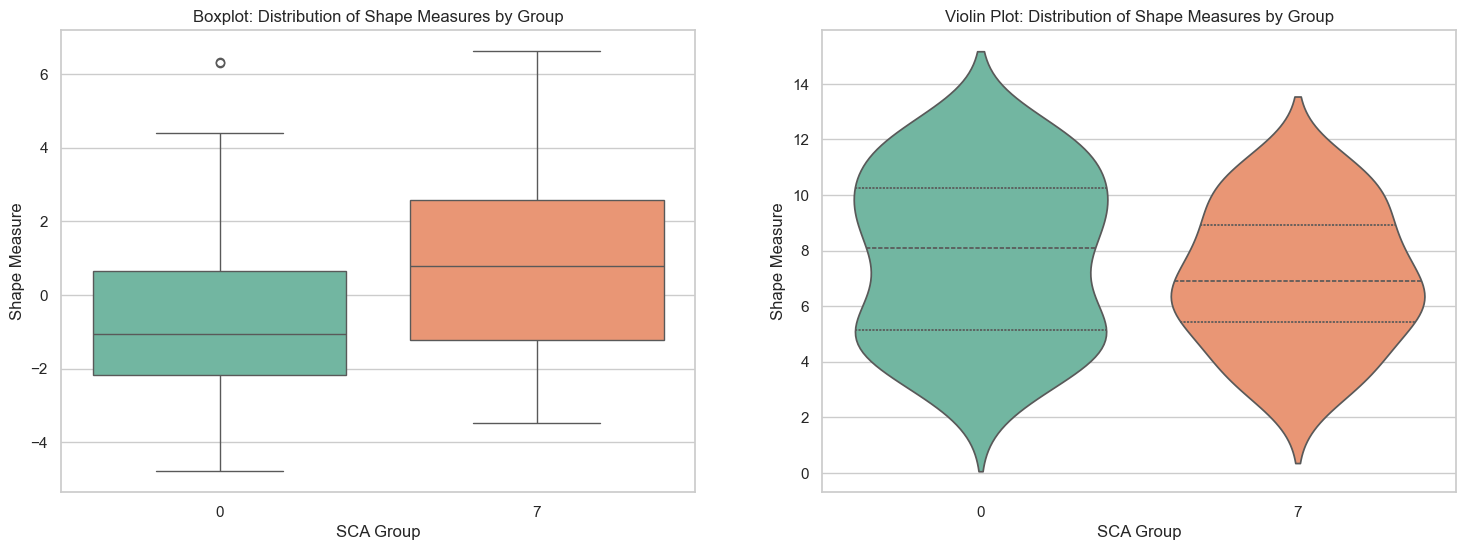

In [100]:
# Compare groups: do the boxplot and violin plots

# Set the style of the visualization
sns.set(style="whitegrid")
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

curVal1 = 'iso3'
curVal2 = 'UMAP1_U2'

# Boxplot
sns.boxplot(x='SCA', y=curVal1, data=combined, palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot: Distribution of Shape Measures by Group')
axes[0].set_xlabel('SCA Group')
axes[0].set_ylabel('Shape Measure')
# Violin Plot
sns.violinplot(x='SCA', y=curVal2, data=combined, palette='Set2', inner='quartile', ax=axes[1])
axes[1].set_title('Violin Plot: Distribution of Shape Measures by Group')
axes[1].set_xlabel('SCA Group')
axes[1].set_ylabel('Shape Measure')

#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots\violin_combined_UMAP1_U3.png')

# Show the plot
plt.show()

In [29]:
#################################  Finding means in the density plot to locate MA  ##################################

In [102]:
# Finding mean of a distribution for MA visualization
data = combined
curSca1 = 0
curSca2 = 7
curVal = 'UMAP1_U2'

summary_stats = data[data['SCA'] == curSca1][curVal].describe()
print(summary_stats)

summary_stats = data[data['SCA'] == curSca2][curVal].describe()
print(summary_stats)

count    70.000000
mean      7.798375
std       2.945402
min       2.575783
25%       5.153872
50%       8.108848
75%      10.267996
max      12.657105
Name: UMAP1_U2, dtype: float64
count    44.000000
mean      7.010076
std       2.446303
min       2.647349
25%       5.436298
50%       6.890702
75%       8.933849
max      11.251232
Name: UMAP1_U2, dtype: float64
